<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/work/notebooks/ContentDeclinePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter
Starter data found. You're ready.


## Data Preprocessing

In [41]:
import pandas as pd
import numpy as np
import warnings
import joblib
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")


## Missing Value Summary

In [42]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values("missing_percentage", ascending=False)
)

display(missing_summary)

,missing_count,missing_percentage
provider_used,21438,71.46
word_count,7699,25.66
char_count,7699,25.66
word_count_tier,7699,25.66
char_count_tier,7699,25.66
model_used,5733,19.11
trend_pct,3388,11.29
competition_level,2610,8.70
search_volume,2468,8.23
cpc,2468,8.23


## Features and Target Definition & Train-Test Split

`GroupShuffleSplit` on `client_id` are being used for avoiding data leakage, so we can train models that are more accurate.

In [43]:
# Let's inspect the target column. Based on the starter data snippet, 'trend_direction' seems to be a target.
# Let's assume the target variable is 'trend_direction' (or adjust as required).
target_col = 'trend_direction'

# Separate numeric columns (excluding ID columns)
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'content_id' in all_numeric_cols:
    all_numeric_cols.remove('content_id')
if 'client_id' in all_numeric_cols:
    all_numeric_cols.remove('client_id')

# Set up GroupShuffleSplit based on 'client_id'
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df[target_col], groups=df['client_id']))

df_train = df.iloc[train_idx]
df_test = df.iloc[test_idx]

X_train_numeric = df_train[all_numeric_cols].copy()
X_test_numeric = df_test[all_numeric_cols].copy()

y_train = df_train[target_col]
y_test = df_test[target_col]

print(f"Train set shape: {X_train_numeric.shape}")
print(f"Test set shape: {X_test_numeric.shape}")

Train set shape: (23837, 30)
Test set shape: (6163, 30)


## Fit and Transform Imputation


In [44]:
# Initialize the imputer
numeric_imputer = SimpleImputer(strategy="mean")

# Fit on train and transform both sets to prevent data leakage
X_train_imputed_array = numeric_imputer.fit_transform(X_train_numeric)
X_test_imputed_array = numeric_imputer.transform(X_test_numeric)

# Convert back to DataFrame using the index from the split DataFrames
X_train_imputed = pd.DataFrame(X_train_imputed_array, columns=all_numeric_cols, index=df_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed_array, columns=all_numeric_cols, index=df_test.index)

print("Missing values remaining in Train:", X_train_imputed.isnull().sum().sum())
print("Missing values remaining in Test:", X_test_imputed.isnull().sum().sum())
display(X_train_imputed.head())

Missing values remaining in Train: 0
Missing values remaining in Test: 0


,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
2,0.0,0.00,0.00,3515.000000,23643.000000,12581.0,11.0,14.0,11.0,11.0,...,3.0,141.0,4.0,20.0,0.09,36.5,0.00,28.57,0.0,-60.9
3,10.0,0.00,0.00,3228.482262,21588.572258,11751.0,58.0,87.0,78.0,75.0,...,26.0,463.0,6.0,22.0,0.49,6.2,1.28,3.45,0.0,-13.8
4,0.0,0.00,0.00,2803.000000,17469.000000,19140.0,24.0,177.0,145.0,144.0,...,9.0,263.0,5.0,14.0,0.13,44.0,0.00,24.29,0.0,-34.7
6,0.0,0.00,0.00,3059.000000,20810.000000,20.0,0.0,1.0,1.0,1.0,...,1.0,90.0,3.0,20.0,0.00,7.0,0.00,0.00,0.0,-92.3
7,590.0,0.44,0.64,3228.482262,21588.572258,1724.0,1.0,28.0,28.0,28.0,...,4.0,445.0,6.0,22.0,0.06,21.2,3.57,7.14,0.0,0.6


## Model Training and Evaluation
Now we will encode the target variable `trend_direction`, fit a Random Forest classifier on the imputed training set, and evaluate its performance on the test set.

In [45]:

# Encode the target labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Initialize and train the classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_imputed, y_train_encoded)

# Predict on the test set
y_pred_encoded = rf_model.predict(X_test_imputed)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Print evaluation results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.9998377413597274

Classification Report:
               precision    recall  f1-score   support

        down       1.00      1.00      1.00      3149
        flat       1.00      1.00      1.00       382
         new       1.00      1.00      1.00       302
      stable       1.00      1.00      1.00      1301
          up       1.00      1.00      1.00      1029

    accuracy                           1.00      6163
   macro avg       1.00      1.00      1.00      6163
weighted avg       1.00      1.00      1.00      6163



## Comprehensive Model Comparison Pipeline
We will now execute the robust model comparison using the provided code framework to evaluate multiple models (Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost) on a leak-free feature set.
It is time to train multiple models that are Logistic Regression, Random Forest, XGBoost, LightGBM and CatBoost on imputed dataset to measure the performance of each model.

In [46]:
# !pip install -q catboost

In [47]:


RANDOM_STATE = 42
LABELS = ["down", "stable", "up"]
LABEL_MAP = {"down": 0, "stable": 1, "up": 2}

# Safe features selection to avoid target leakage
FEATURES = [
    "client_id", "search_volume", "competition", "competition_level", "cpc",
    "content_type", "main_intent", "word_count", "char_count",
    "provider_used", "model_used",
    "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
    "content_age_days", "days_since_last_update",
]

def make_dataset(df):
    df_clean = df.copy()
    # 'flat' is treated as stable; 'new' is excluded
    df_clean["target"] = df_clean["trend_direction"].replace({"flat": "stable"})
    df_clean = df_clean[df_clean["target"].isin(LABELS)].copy()

    X = df_clean[FEATURES].copy()
    y = df_clean["target"].copy()
    return df_clean, X, y

def build_models(X_train, y_train):
    categorical = X_train.select_dtypes(include=["object"]).columns.tolist()
    numeric = [c for c in X_train.columns if c not in categorical]

    pre_scaled = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical),
    ])

    pre_tree = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical),
    ])

    counts = y_train.value_counts()
    class_weights = {k: len(y_train) / (len(counts) * v) for k, v in counts.items()}
    sample_weights = y_train.map(class_weights).values

    models = {
        "logistic_regression": Pipeline([
            ("preprocess", pre_scaled),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)),
        ]),
        "random_forest": Pipeline([
            ("preprocess", pre_scaled),
            ("model", RandomForestClassifier(
                n_estimators=200, min_samples_leaf=2, max_features="sqrt",
                class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
            )),
        ]),
        "xgboost": Pipeline([
            ("preprocess", pre_tree),
            ("model", XGBClassifier(
                n_estimators=300, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                objective="multi:softprob", num_class=3,
                eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
            )),
        ]),
        "lightgbm": Pipeline([
            ("preprocess", pre_tree),
            ("model", LGBMClassifier(
                n_estimators=300, num_leaves=31, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                objective="multiclass", num_class=3,
                class_weight=class_weights,
                random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
            )),
        ]),
    }
    return models, sample_weights, categorical

def evaluate(name, model, X_test, y_test):
    if name == "xgboost":
        pred_ids = model.predict(X_test).astype(int)
        pred = pd.Series(pred_ids).map({0: "down", 1: "stable", 2: "up"}).values
    else:
        pred = model.predict(X_test)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "pred": pred,
    }

In [48]:
df_proc, X, y = make_dataset(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Dataset used:", df_proc.shape)
print("Target distribution:")
print(y.value_counts())
print()

models, sample_weights, categorical = build_models(X_train, y_train)

# Prepare native CatBoost features
Xcb_train = X_train.copy()
Xcb_test = X_test.copy()
for c in categorical:
    Xcb_train[c] = Xcb_train[c].fillna("MISSING").astype(str)
    Xcb_test[c] = Xcb_test[c].fillna("MISSING").astype(str)
cb_counts = y_train.value_counts()
cb_weights = {k: len(y_train) / (len(cb_counts) * v) for k, v in cb_counts.items()}
models["catboost"] = CatBoostClassifier(
    iterations=200, depth=7, learning_rate=0.05, loss_function="MultiClass",
    random_seed=RANDOM_STATE, verbose=False, thread_count=4,
    class_weights=[cb_weights["down"], cb_weights["stable"], cb_weights["up"]]
)

results = []
fitted = {}

for name, model in models.items():
    print(f"Training {name}...")
    if name == "xgboost":
        model.fit(
            X_train,
            y_train.map(LABEL_MAP),
            model__sample_weight=sample_weights,
        )
        eval_X = X_test
    elif name == "catboost":
        model.fit(Xcb_train, y_train, cat_features=categorical)
        eval_X = Xcb_test
    else:
        model.fit(X_train, y_train)
        eval_X = X_test

    r = evaluate(name, model, eval_X, y_test)
    results.append({k: v for k, v in r.items() if k != "pred"})
    fitted[name] = model

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)

Dataset used: (27764, 45)
Target distribution:
target
down      16262
stable     7114
up         4388
Name: count, dtype: int64

Training logistic_regression...
Training random_forest...
Training xgboost...
Training lightgbm...
Training catboost...


## Model Performence Evaluation and Measurement

Each model is being compared in this work with a detailed confusion matrix where each model is callable in the function and score for each model is being compared in the barplot and the best model is visualized with confusion matrix in detail and other models are callable in the function.
The top performing model is found as LIGHTGBM for this project.

In [34]:
def plot_model_confusion_matrix(model_name="lightgbm"):
    """
    Plots a visualized confusion matrix heatmap for a specified model from the trained models.
    Parameters:
    - model_name (str): Name of the model ('lightgbm', 'random_forest', 'xgboost', 'catboost', 'logistic_regression')
    """
    if model_name not in fitted:
        raise ValueError(f"Model '{model_name}' not found. Available models are: {list(fitted.keys())}")

    # Retrieve model and generate evaluation predictions
    model = fitted[model_name]
    eval_X = Xcb_test if model_name == "catboost" else X_test

    # Obtain predictions dynamically
    eval_res = evaluate(model_name, model, eval_X, y_test)
    preds = eval_res["pred"]

    # Generate and plot Confusion Matrix
    cm = confusion_matrix(y_test, preds, labels=LABELS)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.title(f"Confusion Matrix: {model_name.upper()}" + (" (Best Model)" if model_name == "lightgbm" else ""), fontsize=14, pad=15)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.show()


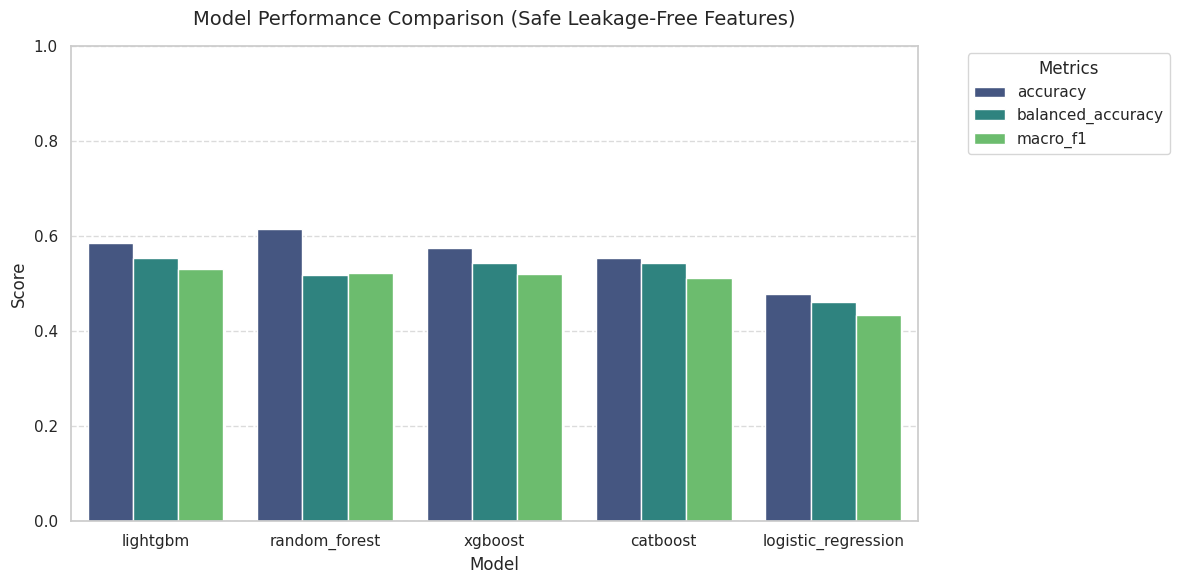

In [31]:

# Prepare results for visualization
plot_df = results_df.melt(id_vars="model", value_vars=["accuracy", "balanced_accuracy", "macro_f1"],
                          var_name="metric", value_name="score")

# Plot Model Metrics Comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric", palette="viridis")
plt.title("Model Performance Comparison (Safe Leakage-Free Features)", fontsize=14, pad=15)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

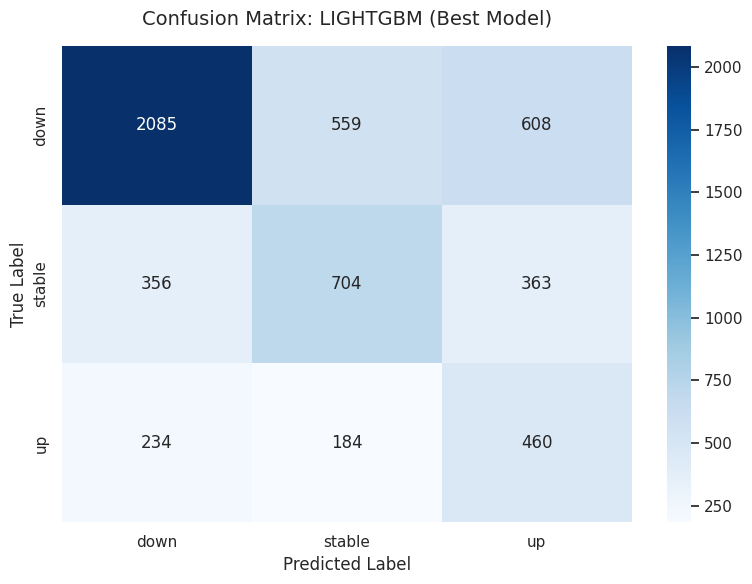

In [39]:
# To visualize other modelsi adjust the model name with:
#'random_forest', 'xgboost', 'catboost', 'logistic_regression'
plot_model_confusion_matrix(model_name="lightgbm")
